In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
from tcn import TCN
import os

In [4]:
data = pd.read_csv("data/workingdataset3.csv")
X = data.iloc[:, :-1]
y = data.iloc[:, -1]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
y = to_categorical(y)

In [5]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.to_numpy()
X_val = X_val.to_numpy()
X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)

In [6]:
num_classes = y.shape[-1]
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    TCN(nb_filters=32, kernel_size=3, dilations=[1,2,4,8], dropout_rate=0.2),
    Dense(num_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=60, batch_size=16)


Epoch 1/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - accuracy: 0.3498 - loss: 1.9577 - val_accuracy: 0.5536 - val_loss: 1.6184
Epoch 2/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.4664 - loss: 1.6856 - val_accuracy: 0.5536 - val_loss: 1.4110
Epoch 3/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.4753 - loss: 1.6327 - val_accuracy: 0.5357 - val_loss: 1.3756
Epoch 4/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.4978 - loss: 1.4711 - val_accuracy: 0.5536 - val_loss: 1.2883
Epoch 5/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.4664 - loss: 1.5690 - val_accuracy: 0.5536 - val_loss: 1.2884
Epoch 6/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.4933 - loss: 1.4347 - val_accuracy: 0.5536 - val_loss: 1.3049
Epoch 7/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.4709 - loss: 1.5078 - val_accuracy: 0.5536 - val_loss: 1.2500
Epoch 8/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.4888 - loss: 1.4910 - val_accuracy: 0.5536 -

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step


d:\Anaconda\envs\epf\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


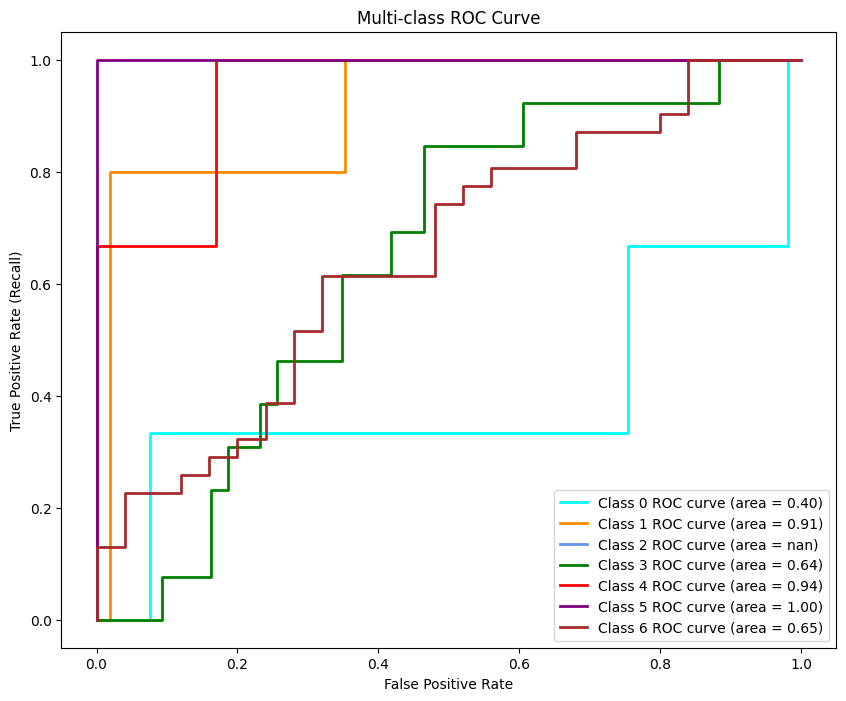

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from itertools import cycle

y_score = model.predict(X_val)

y_true = y_val 

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown'])
for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {i} ROC curve (area = {roc_auc[i]:.2f})')


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


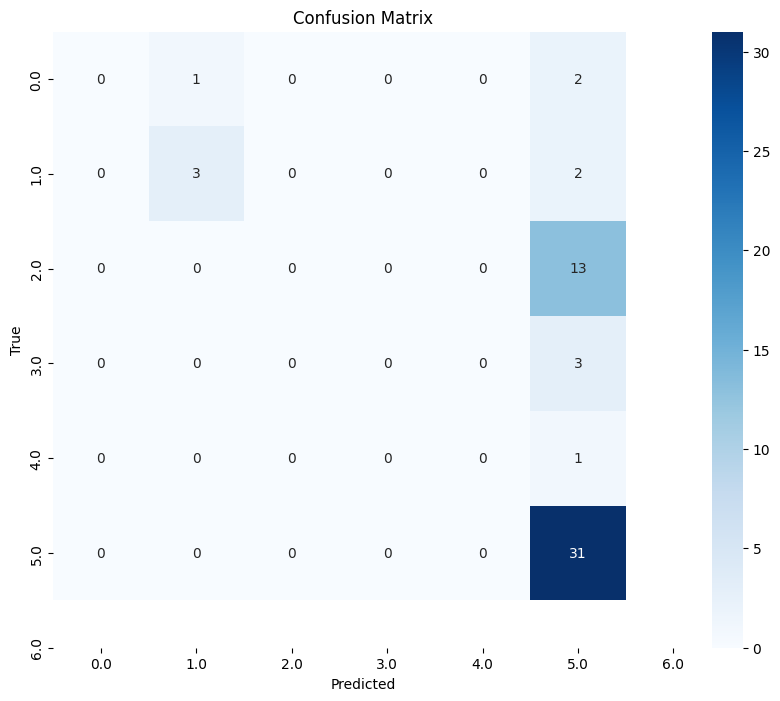

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# For multi-class, convert y_val back to labels
y_true = np.argmax(y_val, axis=1)
y_pred = np.argmax(model.predict(X_val), axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

##Without Healthy

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
from tcn import TCN
import os

In [10]:
data = pd.read_csv("data/workingdataset3_withouthealthy.csv")
X = data.iloc[:, :-1]
y = data.iloc[:, -1]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
y = to_categorical(y)

In [11]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.to_numpy()
X_val = X_val.to_numpy()
X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)

In [12]:
num_classes = y.shape[-1]
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    TCN(nb_filters=32, kernel_size=3, dilations=[1,2,4,8], dropout_rate=0.2),
    Dense(num_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=60, batch_size=16)

Epoch 1/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 153ms/step - accuracy: 0.3514 - loss: 1.9405 - val_accuracy: 0.5357 - val_loss: 1.6468
Epoch 2/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.3694 - loss: 1.7141 - val_accuracy: 0.5000 - val_loss: 1.5970
Epoch 3/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.4054 - loss: 1.6957 - val_accuracy: 0.5000 - val_loss: 1.5629
Epoch 4/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.4505 - loss: 1.6002 - val_accuracy: 0.5357 - val_loss: 1.5143
Epoch 5/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.4775 - loss: 1.5562 - val_accuracy: 0.5357 - val_loss: 1.4617
Epoch 6/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.4865 - loss: 1.5162 - val_accuracy: 0.5357 - val_loss: 1.4247
Epoch 7/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.4865 - loss: 1.5179 - val_accuracy: 0.5357 - val_loss: 1.4057
Epoch 8/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.4685 - loss: 1.4643 - val_accuracy: 0.5357 - val_loss:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step


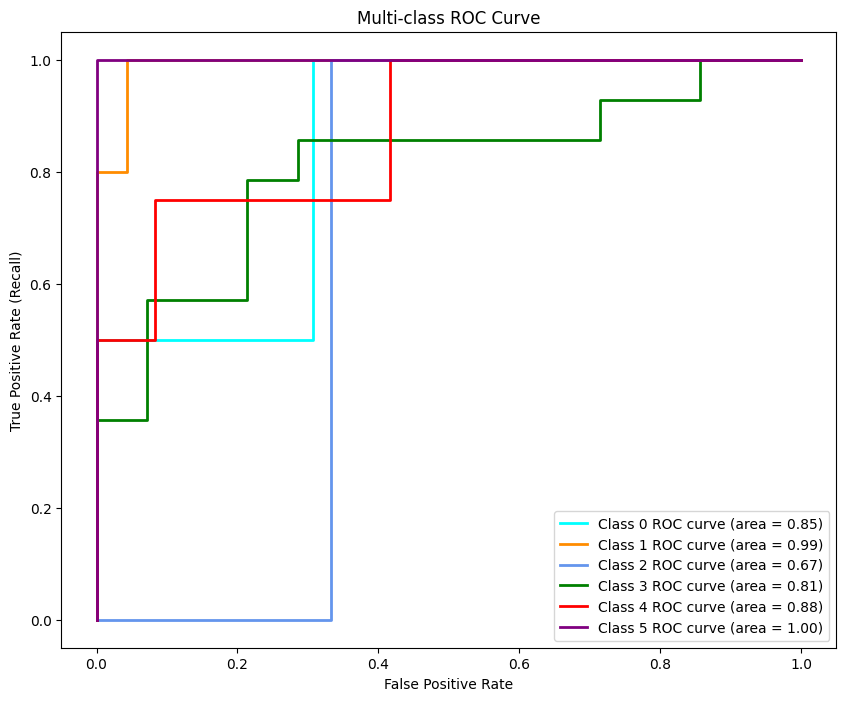

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from itertools import cycle

y_score = model.predict(X_val)

y_true = y_val 

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown'])
for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {i} ROC curve (area = {roc_auc[i]:.2f})')


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


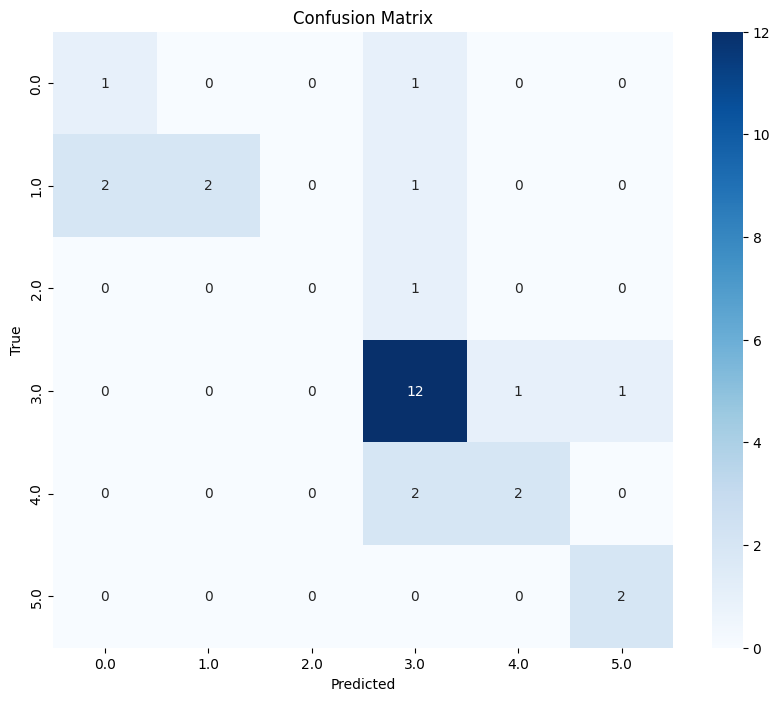

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# For multi-class, convert y_val back to labels
y_true = np.argmax(y_val, axis=1)
y_pred = np.argmax(model.predict(X_val), axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()